In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # grafy, vizualizacie dat
import seaborn as sb # graficka kniznica
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import BaggingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report
from imblearn.metrics import classification_report_imbalanced
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_score, cross_val_predict
from datetime import datetime
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path= '/content/drive/MyDrive/Colab Notebooks/CSV_files/asthma_disease_data.csv'

In [ ]:
data = pd.read_csv(path)

In [ ]:
type(data)


pandas.core.frame.DataFrame

In [ ]:
data.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0


In [ ]:
data_n=data.drop(columns=['PatientID','DoctorInCharge'])
data_n[['Age','BMI','PhysicalActivity','DietQuality','SleepQuality','PollutionExposure','PollenExposure','DustExposure','LungFunctionFEV1','LungFunctionFVC']].kurtosis()

,0
Age,-1.198606
BMI,-1.216925
PhysicalActivity,-1.193707
DietQuality,-1.210175
SleepQuality,-1.205281
PollutionExposure,-1.240942
PollenExposure,-1.215373
DustExposure,-1.195892
LungFunctionFEV1,-1.171220
LungFunctionFVC,-1.192936


In [ ]:
# Trying all combinations: normalised/discrete values, oversampling/undersampling - 4 possibilities for all models

In [ ]:
target_col = 'Diagnosis' # cieľový atribút
exp_cols = ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
            'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy','FamilyHistoryAsthma','HistoryOfAllergies','Eczema',
            'HayFever','GastroesophagealReflux','LungFunctionFEV1','LungFunctionFVC','Wheezing','ShortnessOfBreath','ChestTightness',
            'Coughing','NighttimeSymptoms','ExerciseInduced']
data_n
# Making values of attributes normalised.
x = data_n.values
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
data_N = pd.DataFrame(x_scaled)

data_N.columns=['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
                'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy','FamilyHistoryAsthma','HistoryOfAllergies','Eczema',
                'HayFever','GastroesophagealReflux','LungFunctionFEV1','LungFunctionFVC','Wheezing','ShortnessOfBreath','ChestTightness',
                'Coughing','NighttimeSymptoms','ExerciseInduced','Diagnosis']

X = data_N[exp_cols]
y = data_N[target_col]
data_N

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,0.783784,0.0,0.333333,0.000000,0.032738,0.0,0.089324,0.548738,0.783941,0.738898,...,0.0,0.122894,0.764809,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.283784,1.0,0.666667,0.666667,0.309582,0.0,0.589909,0.633997,0.192255,0.196922,...,0.0,0.399201,0.044973,1.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.702703,0.0,0.666667,0.333333,0.134793,0.0,0.674163,0.919608,0.473612,0.145987,...,0.0,0.232575,0.782888,1.0,1.0,1.0,0.0,1.0,1.0,0.0
3,0.472973,1.0,0.666667,0.333333,0.941078,0.0,0.140359,0.582532,0.041970,0.058100,...,0.0,0.677360,0.177828,1.0,0.0,1.0,1.0,1.0,0.0,0.0
4,0.756757,0.0,0.000000,1.000000,0.170395,0.0,0.460548,0.312499,0.938207,0.098005,...,0.0,0.823580,0.348470,1.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,0.513514,1.0,0.000000,0.666667,0.562151,0.0,0.301990,0.611852,0.717209,0.248332,...,0.0,0.708438,0.814777,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2388,0.175676,1.0,0.000000,0.333333,0.228785,0.0,0.580688,0.438533,0.622165,0.773455,...,0.0,0.044184,0.891114,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2389,0.662162,0.0,1.000000,0.666667,0.883543,0.0,0.473624,0.821360,0.580851,0.279440,...,0.0,0.228557,0.410464,1.0,0.0,1.0,1.0,0.0,1.0,1.0
2390,0.554054,1.0,0.000000,0.666667,0.337139,0.0,0.967664,0.736213,0.453032,0.944978,...,1.0,0.827234,0.047391,0.0,1.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
# Making values of attributes discrete
est = preprocessing.KBinsDiscretizer(n_bins=5, encode='ordinal',strategy="uniform")
est.fit(data_N)
Xt=est.fit_transform(data_N)
data_D=pd.DataFrame(Xt)
data_D.columns=['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
                'PhysicalActivity', 'DietQuality', 'SleepQuality', 'PollutionExposure',
                'PollenExposure', 'DustExposure', 'PetAllergy','FamilyHistoryAsthma','HistoryOfAllergies',
                'Eczema','HayFever','GastroesophagealReflux','LungFunctionFEV1','LungFunctionFVC',
                'Wheezing','ShortnessOfBreath','ChestTightness','Coughing','NighttimeSymptoms','ExerciseInduced','Diagnosis']
data_D
X_D = data_D[exp_cols]
y_D = data_D[target_col]

In [ ]:
# Undersampling dataset in order to balance all target classes
rus = RandomUnderSampler()
X_und, y_und = rus.fit_resample(X, y)
XD_und, yD_und = rus.fit_resample(X_D, y_D)
print('Resampled dataset shape %s' % Counter(y_und))
yD_und

Resampled dataset shape Counter({0.0: 124, 1.0: 124})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


,Diagnosis
1107,0.0
1048,0.0
902,0.0
1001,0.0
120,0.0
...,...
2381,4.0
2384,4.0
2387,4.0
2388,4.0


In [ ]:
# Oversampling dataset to balance all target classes
sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)
XD_res, yD_res = sm.fit_resample(X_D, y_D)
print('Resampled dataset shape %s' % Counter(y_res))
y_res

Resampled dataset shape Counter({0.0: 2268, 1.0: 2268})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validatio

,Diagnosis
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
4531,1.0
4532,1.0
4533,1.0
4534,1.0


In [ ]:
# Creating training and testing datasets - all combinations are necessary to be divided here.
XD_und_train, XD_und_test, yD_und_train, yD_und_test = train_test_split(XD_und,yD_und,test_size=0.33)

1. RandomForestClassifier

0:00:00.345467
              precision    recall  f1-score   support

         0.0       0.40      0.36      0.38        39
         4.0       0.47      0.51      0.49        43

    accuracy                           0.44        82
   macro avg       0.43      0.44      0.43        82
weighted avg       0.44      0.44      0.44        82



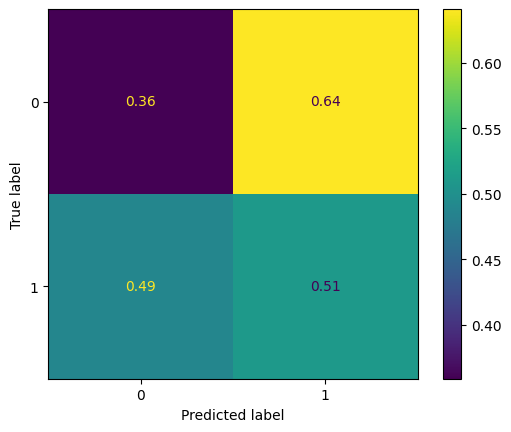

In [ ]:
startTime = datetime.now()
rf = RandomForestClassifier(max_depth=4, criterion='gini')
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
print(datetime.now() - startTime)
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

2. DecisionTree

0:00:00.015024
              precision    recall  f1-score   support

         0.0       0.41      0.41      0.41        37
         4.0       0.51      0.51      0.51        45

    accuracy                           0.46        82
   macro avg       0.46      0.46      0.46        82
weighted avg       0.46      0.46      0.46        82



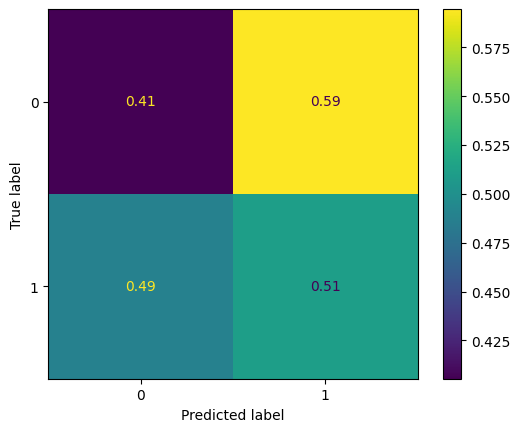

In [ ]:
startTime = datetime.now()
from sklearn.tree import DecisionTreeClassifier
clf3 = DecisionTreeClassifier(max_depth=8,criterion='entropy')
clf3.fit(X_train, y_train)
y_pred=clf3.predict(X_test)
print(datetime.now() - startTime)
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
br = BalancedRandomForestClassifier(class_weight='balanced_subsample')
br.fit(X,y)
y_pred4=clf3.predict(X_test)
print(classification_report_imbalanced(y_test,y_pred4))

/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.

                   pre       rec       spe        f1       geo       iba       sup

        0.0       1.00      0.60      0.94      0.75      0.75      0.54       755
        1.0       0.10      0.94      0.60      0.18      0.75      0.58        35

avg / total       0.96      0.61      0.93      0.72      0.75      0.54       790



/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and w

3. BaggingClassifier

In [ ]:
bbc = BaggingClassifier()
bbc.fit(X_train,y_train)
y_pred = bbc.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[728   2]
 [ 42 725]]
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97       730
         4.0       1.00      0.95      0.97       767

    accuracy                           0.97      1497
   macro avg       0.97      0.97      0.97      1497
weighted avg       0.97      0.97      0.97      1497



4. Naive Bayes

0:00:00.011114
              precision    recall  f1-score   support

         0.0       0.62      0.43      0.51        47
         4.0       0.46      0.66      0.54        35

    accuracy                           0.52        82
   macro avg       0.54      0.54      0.52        82
weighted avg       0.55      0.52      0.52        82



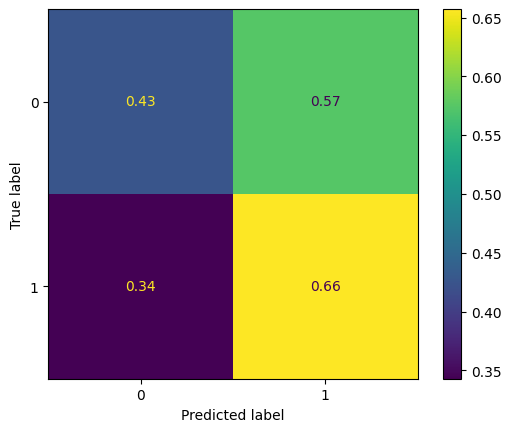

In [ ]:
startTime = datetime.now()
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
trained_model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(datetime.now() - startTime)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

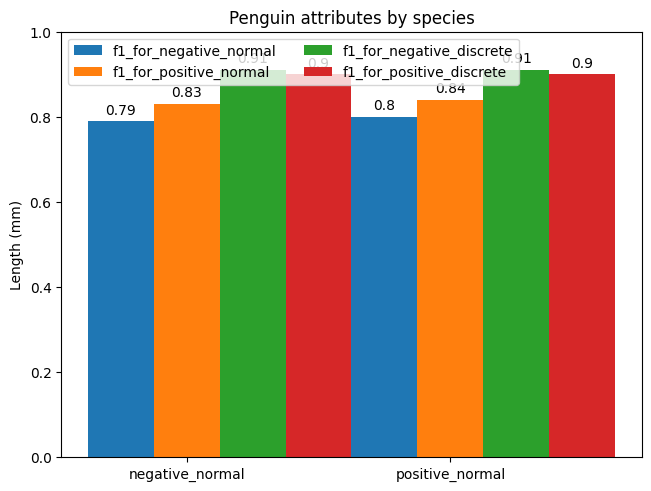

In [ ]:
#https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html#sphx-glr-gallery-lines-bars-and-markers-barchart-py - nezabudni urobit grouped bar ploty na F1-score, precision, ... A taktiez dopisat popis pouzitych algoritmov(RandomUnderSampling, SMOTE, MinMaxScaler - normalizacia, Diskretizacia), aby si to mal cele a tiez aj vyhodnotenie (zaver)
# just a code for
import numpy as np

species = ("negative_normal", "positive_normal", "negative_discrete", "positive_discrete")
metrics_DT_entropy = {
    'f1_for_negative_normal': (0.79,0.80),
    'f1_for_positive_normal': (0.83, 0.84),
    'f1_for_negative_discrete': (0.91,0.91),
    'f1_for_positive_discrete': (0.90, 0.90)
}

metrics_DT_gini = {
    'f1_for_negative_normal': (0.79,0.80),
    'f1_for_positive_normal': (0.83, 0.84),
    'f1_for_negative_discrete': (0.91,0.91),
    'f1_for_positive_discrete': (0.90, 0.90)
}

x = np.arange(len(species))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
extra_space = 0.25

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in metrics_RF.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0, 1)

plt.show()